# CUSTOMER SHOPPING BEHAVIOUR ANALYSIS

In [56]:
# Loading the dataset using pandas

import pandas as pd

df = pd.read_csv('customer_shopping_behavior.csv')

In [57]:
df.head() 

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [58]:
df.info() #structure of data --> how many rows or columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [59]:
# Summary statistics using .describe()
df.describe(include='all') #df.describe() --> shows only details of numeric columns so, we use include='all'

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [60]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [61]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [62]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [63]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [64]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [65]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [66]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [67]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [68]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [69]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [70]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [71]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [72]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

## Code for MySQL

In [73]:
%pip install pymysql sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [74]:
import pymysql

connection = pymysql.connect(
    host="localhost",
    user="root",
    password="your_password",
    port=3306,
    database="customer_behavior"
)

print("MySQL connection successful!")
connection.close()

MySQL connection successful!


In [75]:
import pymysql

connection = pymysql.connect(
    host="localhost",
    user="root",
    password="your_password",
    port=3306
)

print("PyMySQL connection successful!")

connection.close()

PyMySQL connection successful!


In [76]:
connection = pymysql.connect(
    host="localhost",
    user="root",
    password="your_password",
    port=3306,
    database="customer_behavior"
)

print("Database connection successful!")

connection.close()

Database connection successful!


In [77]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="your_password",
    host="localhost",
    port=3306,
    database="customer_behavior"
)

engine = create_engine(connection_url)

with engine.connect() as conn:
    print("SQLAlchemy connection successful!")

SQLAlchemy connection successful!


In [78]:
table_name = "customer"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}' in database.")

Data successfully loaded into table 'customer' in database.


In [79]:
result = pd.read_sql(
    "SELECT * FROM customer LIMIT 5;",
    engine
)

result

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


## 📊 Retail Customer Behavior — Matplotlib Dashboard

'''This section converts the cleaned dataset into a presentation-ready analytics report using **Matplotlib**.  
All charts are generated directly inside this Jupyter Notebook so the project does not depend on Power BI.

### Report sections
1. Executive KPIs
2. Customer demographics
3. Product & category performance
4. Subscription & promotion analysis
5. Shopping behavior
6. Business insights'''


In [80]:
# Reporting libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Consistent notebook-wide plotting settings
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120
})

# Create a folder for exported report charts
from pathlib import Path
chart_dir = Path("matplotlib_report_charts")
chart_dir.mkdir(exist_ok=True)

print("Reporting section ready.")


Reporting section ready.


## 1.Executive KPIs

In [81]:

total_revenue = df["purchase_amount"].sum()
total_transactions = len(df)
avg_purchase = df["purchase_amount"].mean()
avg_rating = df["review_rating"].mean()
discount_rate = (df["discount_applied"].eq("Yes").mean()) * 100
subscriber_count = df["subscription_status"].eq("Yes").sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Transactions",
        "Average Purchase",
        "Average Rating",
        "Discount Rate",
        "Subscribers"
    ],
    "Value": [
        f"${total_revenue:,.0f}",
        f"{total_transactions:,}",
        f"${avg_purchase:,.2f}",
        f"{avg_rating:.2f} / 5",
        f"{discount_rate:.1f}%",
        f"{subscriber_count:,}"
    ]
})

display(kpis)


,KPI,Value
0,Total Revenue,"$233,081"
1,Transactions,"3,900"
2,Average Purchase,$59.76
3,Average Rating,3.75 / 5
4,Discount Rate,43.0%
5,Subscribers,"1,053"


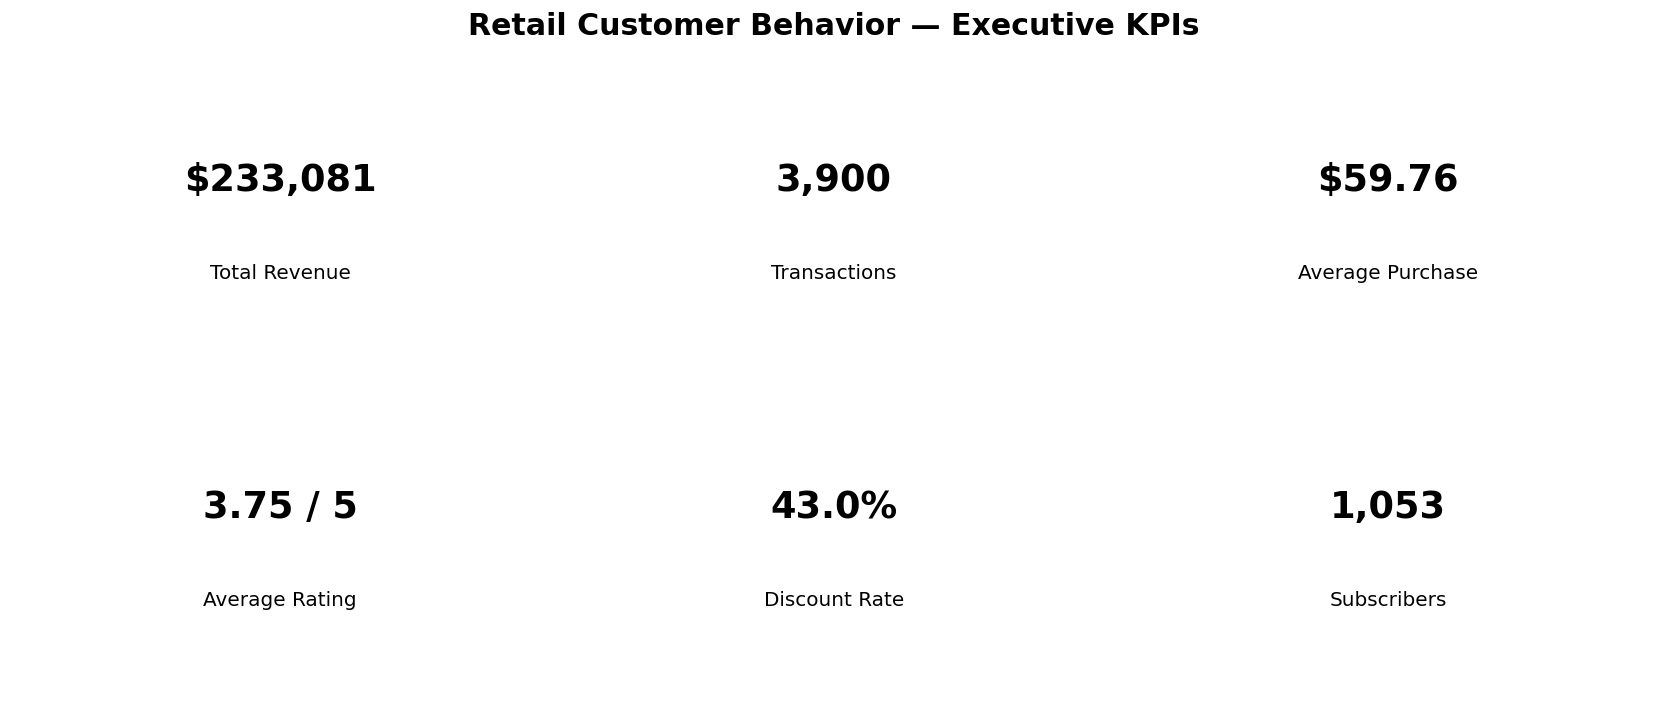

In [82]:
# KPI dashboard-style visual
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("Retail Customer Behavior — Executive KPIs", fontsize=18, fontweight="bold")

for ax, (_, row) in zip(axes.flat, kpis.iterrows()):
    ax.axis("off")
    ax.text(0.5, 0.62, row["Value"], ha="center", va="center",
            fontsize=22, fontweight="bold")
    ax.text(0.5, 0.32, row["KPI"], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig(chart_dir / "01_executive_kpis.png", bbox_inches="tight")
plt.show()


## 2. Customer Demographics & Segmentation

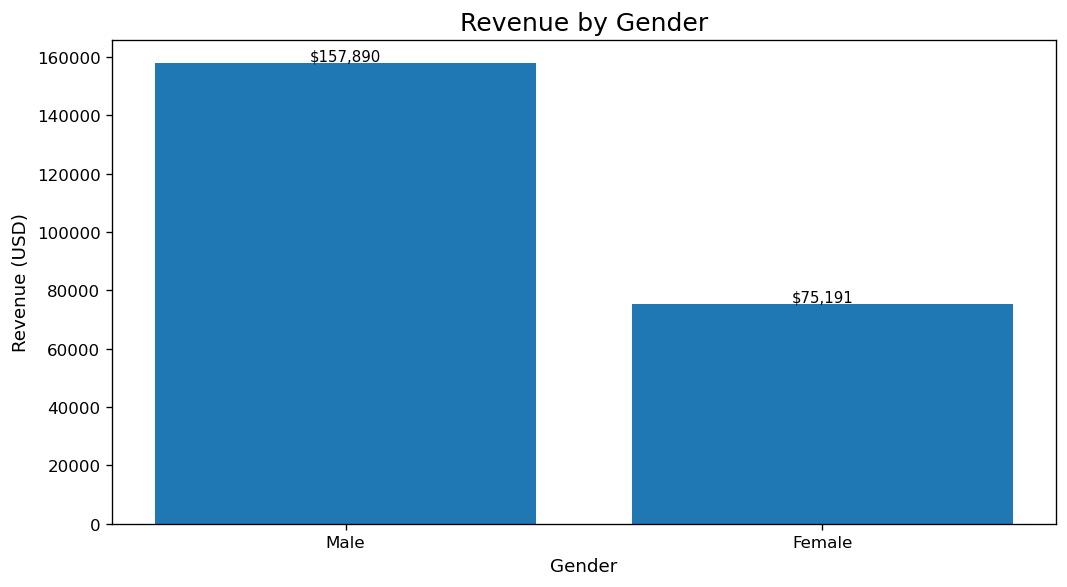

In [83]:
# Revenue by gender
gender_revenue = df.groupby("gender")["purchase_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(gender_revenue.index, gender_revenue.values)
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=0)

for bar, value in zip(bars, gender_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"${value:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "02_revenue_by_gender.png", bbox_inches="tight")
plt.show()


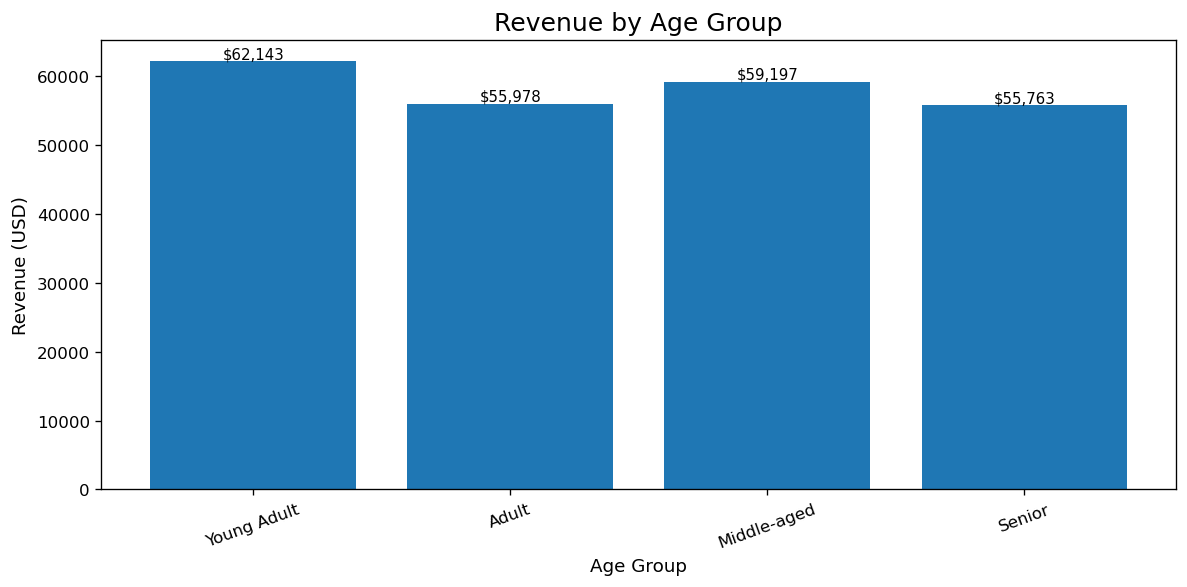

In [84]:
# Revenue by age group
age_revenue = df.groupby("age_group", observed=False)["purchase_amount"].sum()

plt.figure(figsize=(10, 5))
bars = plt.bar(age_revenue.index.astype(str), age_revenue.values)
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=20)

for bar, value in zip(bars, age_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"${value:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "03_revenue_by_age_group.png", bbox_inches="tight")
plt.show()


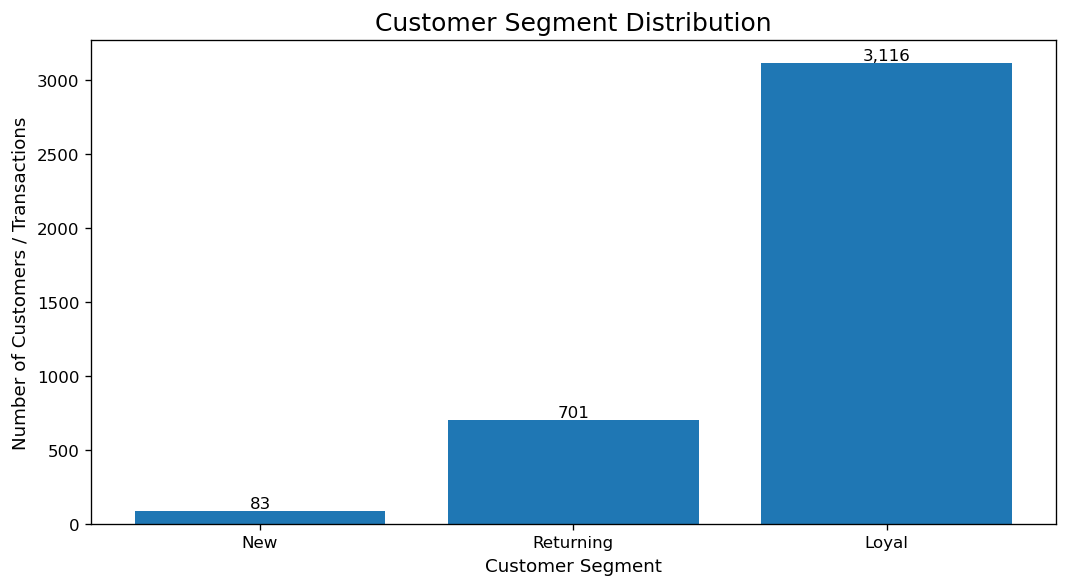

In [85]:
# Customer segment
# Based on previous purchases: New = 1, Returning = 2–10, Loyal = >10
df["customer_segment"] = pd.cut(
    df["previous_purchases"],
    bins=[0, 1, 10, float("inf")],
    labels=["New", "Returning", "Loyal"],
    include_lowest=True
)

segment_counts = df["customer_segment"].value_counts().reindex(
    ["New", "Returning", "Loyal"]
)

plt.figure(figsize=(9, 5))
bars = plt.bar(segment_counts.index.astype(str), segment_counts.values)
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers / Transactions")

for bar, value in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(chart_dir / "04_customer_segments.png", bbox_inches="tight")
plt.show()


## 3. Product & Category Performance

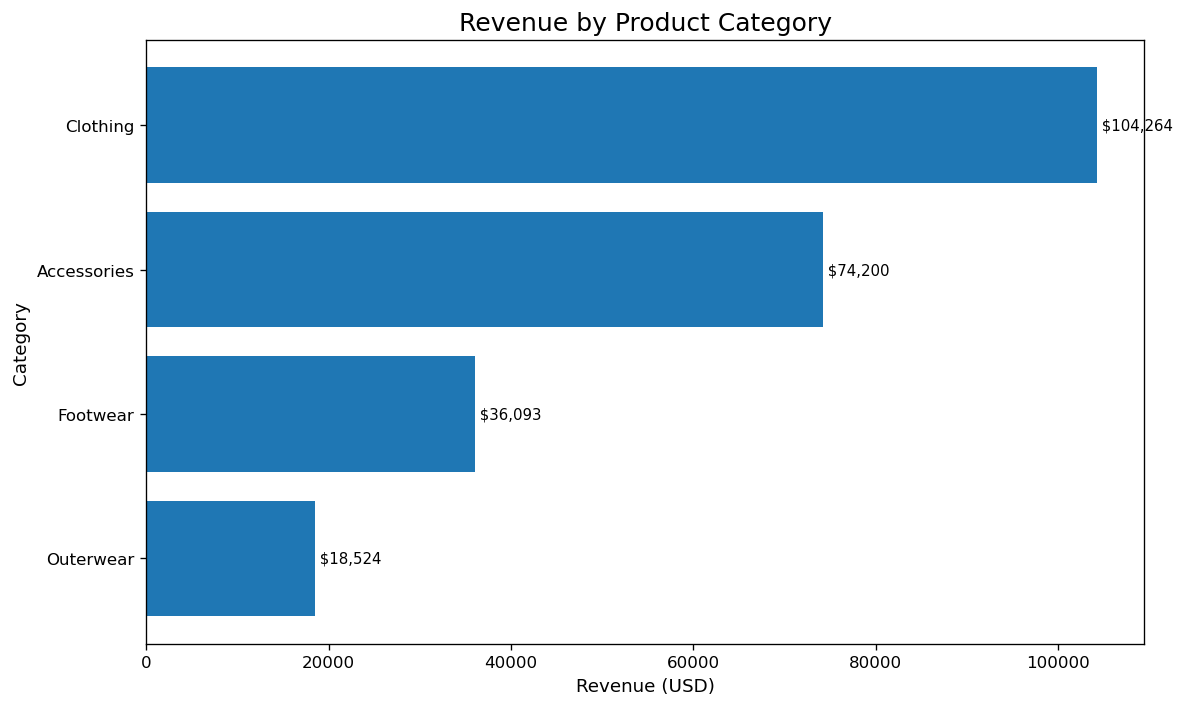

In [86]:
# Revenue by category
category_revenue = (
    df.groupby("category")["purchase_amount"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(category_revenue.index, category_revenue.values)
plt.title("Revenue by Product Category")
plt.xlabel("Revenue (USD)")
plt.ylabel("Category")

for bar, value in zip(bars, category_revenue.values):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" ${value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "05_revenue_by_category.png", bbox_inches="tight")
plt.show()


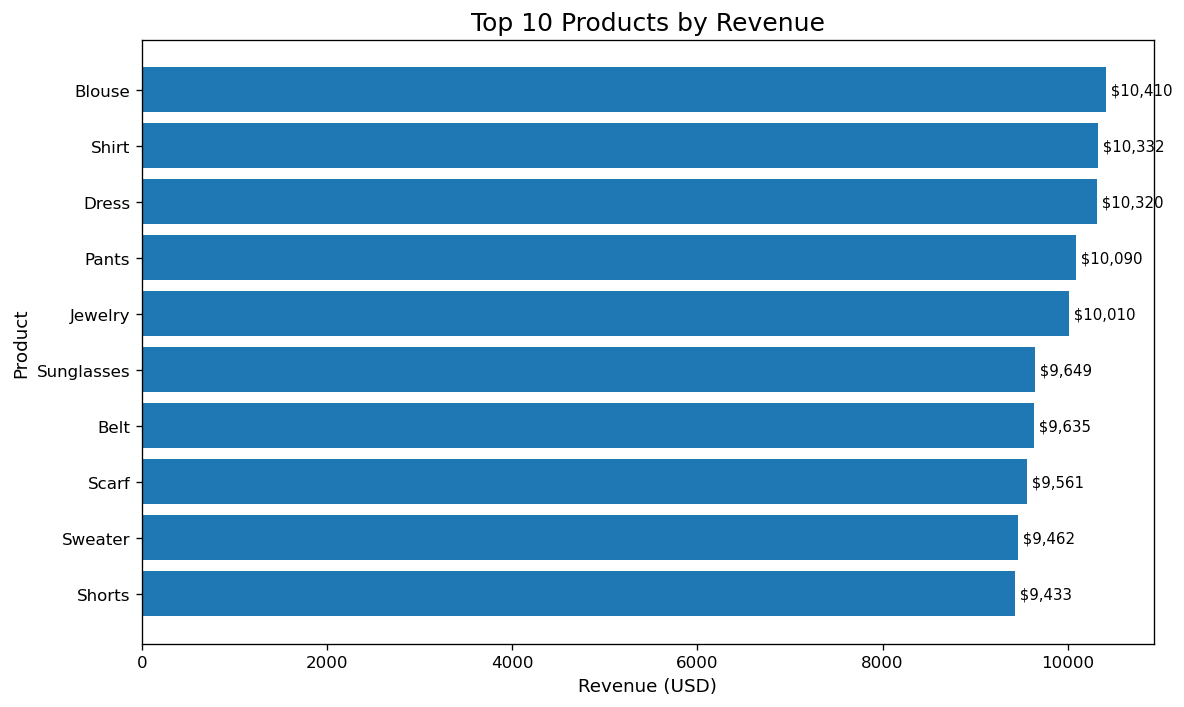

In [87]:
# Top 10 products by revenue
top_products = (
    df.groupby("item_purchased")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product")

for bar, value in zip(bars, top_products.values):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" ${value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "06_top_10_products.png", bbox_inches="tight")
plt.show()


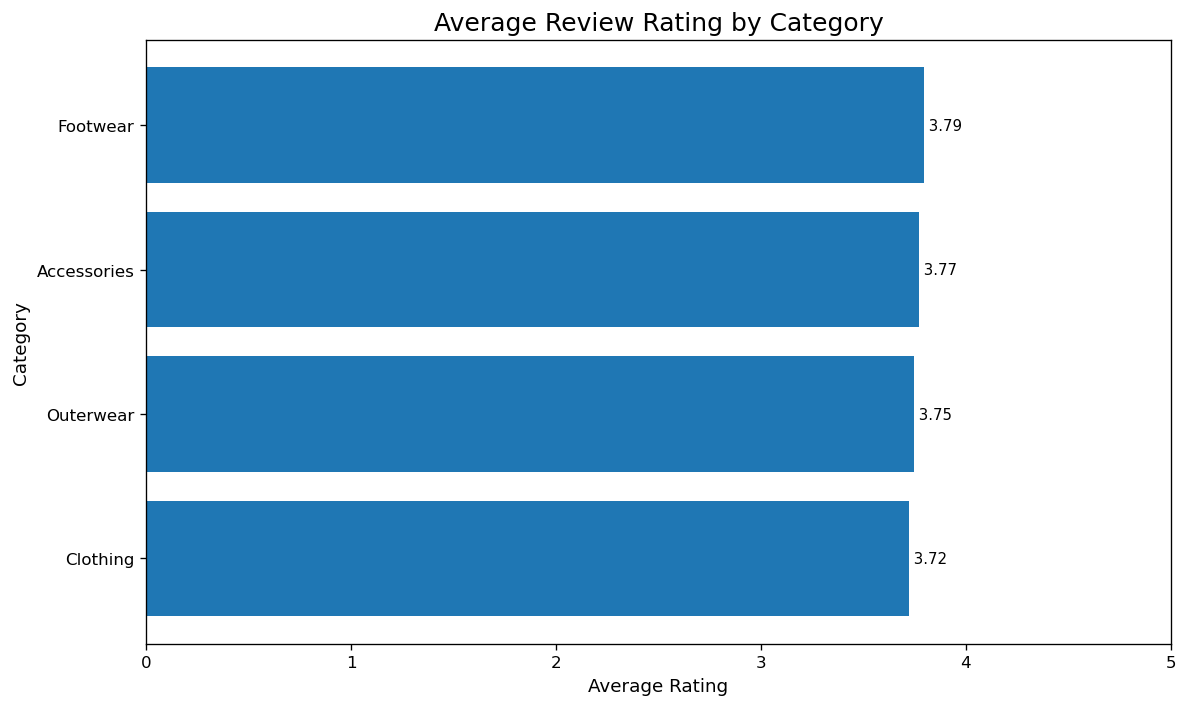

In [88]:
# Average review rating by category
category_rating = (
    df.groupby("category")["review_rating"]
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(category_rating.index, category_rating.values)
plt.title("Average Review Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)

for bar, value in zip(bars, category_rating.values):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" {value:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "07_category_ratings.png", bbox_inches="tight")
plt.show()


## 4. Subscription & Promotion Analysis

,Transactions,Revenue,Avg_Purchase
subscription_status,,,
No,2847,170436,59.87
Yes,1053,62645,59.49


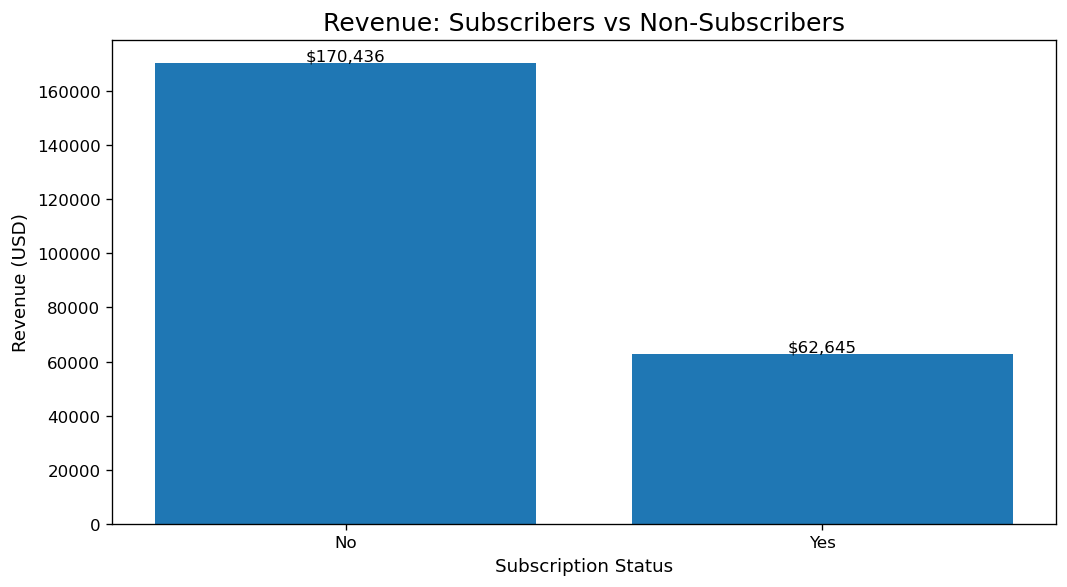

In [89]:
# Subscription status comparison
subscription_summary = (
    df.groupby("subscription_status")
      .agg(
          Transactions=("customer_id", "count"),
          Revenue=("purchase_amount", "sum"),
          Avg_Purchase=("purchase_amount", "mean")
      )
)

display(subscription_summary.round(2))

plt.figure(figsize=(9, 5))
bars = plt.bar(
    subscription_summary.index,
    subscription_summary["Revenue"]
)
plt.title("Revenue: Subscribers vs Non-Subscribers")
plt.xlabel("Subscription Status")
plt.ylabel("Revenue (USD)")

for bar, value in zip(bars, subscription_summary["Revenue"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"${value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(chart_dir / "08_subscription_revenue.png", bbox_inches="tight")
plt.show()


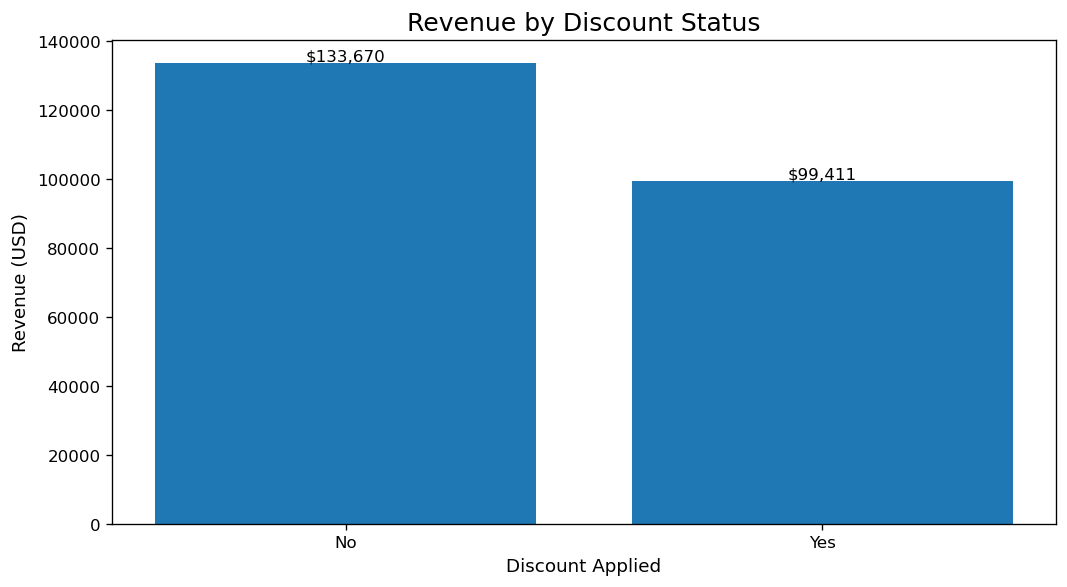

In [90]:
# Discounted vs non-discounted revenue
discount_summary = (
    df.groupby("discount_applied")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(discount_summary.index, discount_summary.values)
plt.title("Revenue by Discount Status")
plt.xlabel("Discount Applied")
plt.ylabel("Revenue (USD)")

for bar, value in zip(bars, discount_summary.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"${value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(chart_dir / "09_discount_revenue.png", bbox_inches="tight")
plt.show()


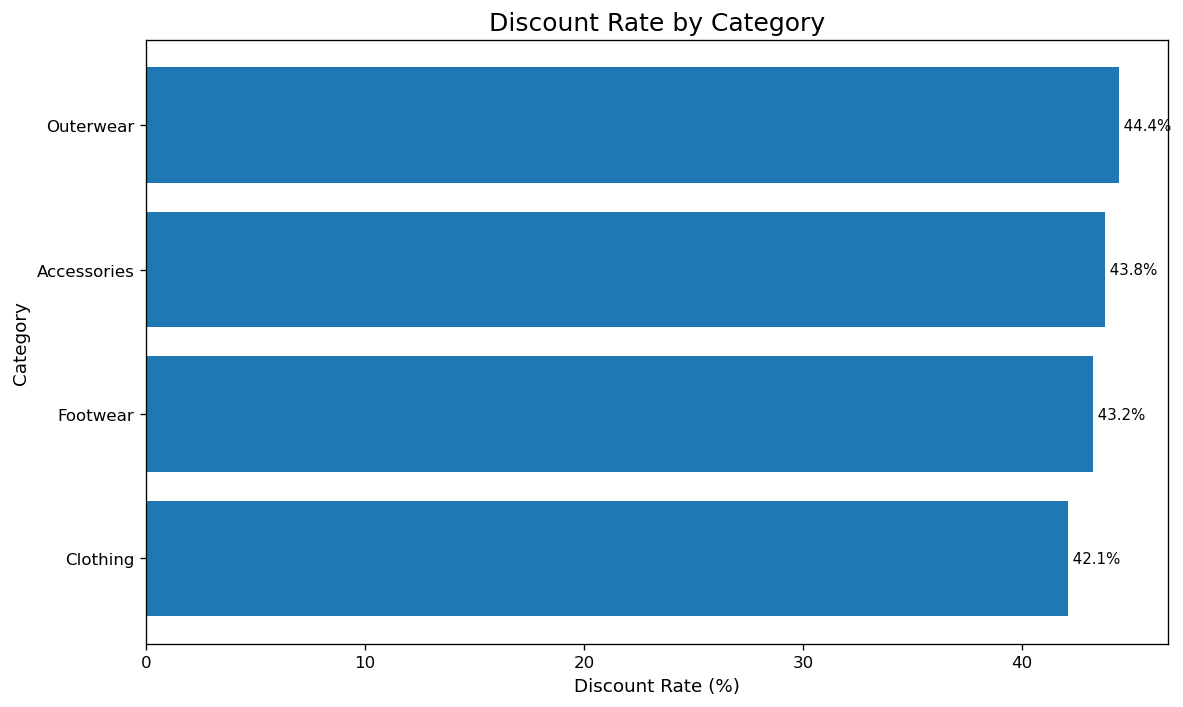

In [91]:
# Discount rate by category
discount_by_category = (
    df.groupby("category")["discount_applied"]
      .apply(lambda x: x.eq("Yes").mean() * 100)
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(discount_by_category.index, discount_by_category.values)
plt.title("Discount Rate by Category")
plt.xlabel("Discount Rate (%)")
plt.ylabel("Category")

for bar, value in zip(bars, discount_by_category.values):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" {value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "10_discount_rate_by_category.png", bbox_inches="tight")
plt.show()


## 5. Shopping Behavior

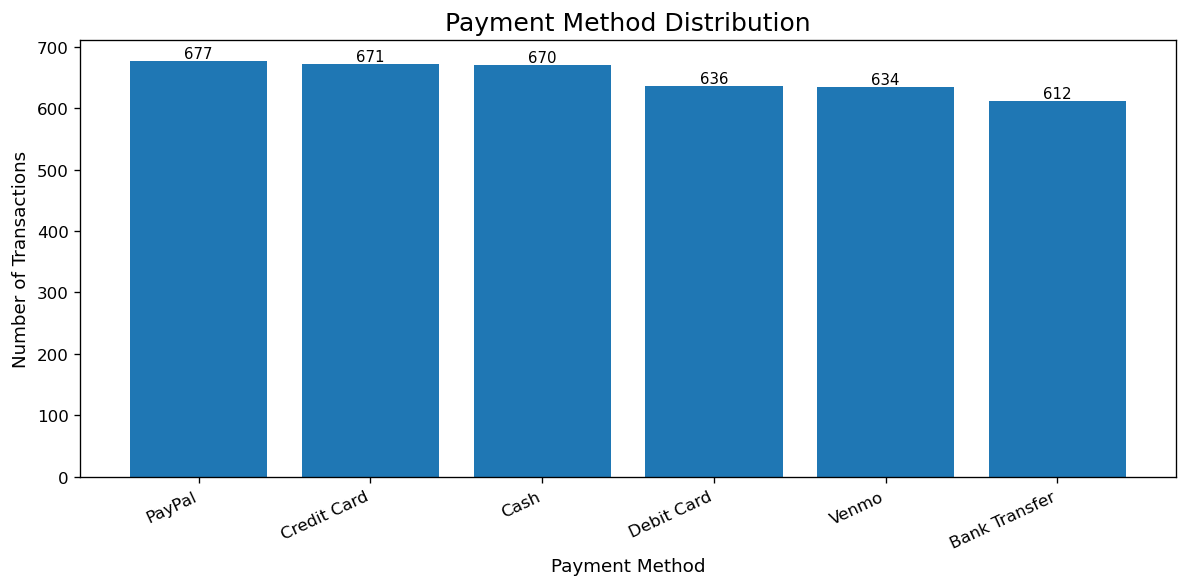

In [92]:
# Payment method distribution
payment_counts = df["payment_method"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(payment_counts.index, payment_counts.values)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, payment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{value:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "11_payment_methods.png", bbox_inches="tight")
plt.show()


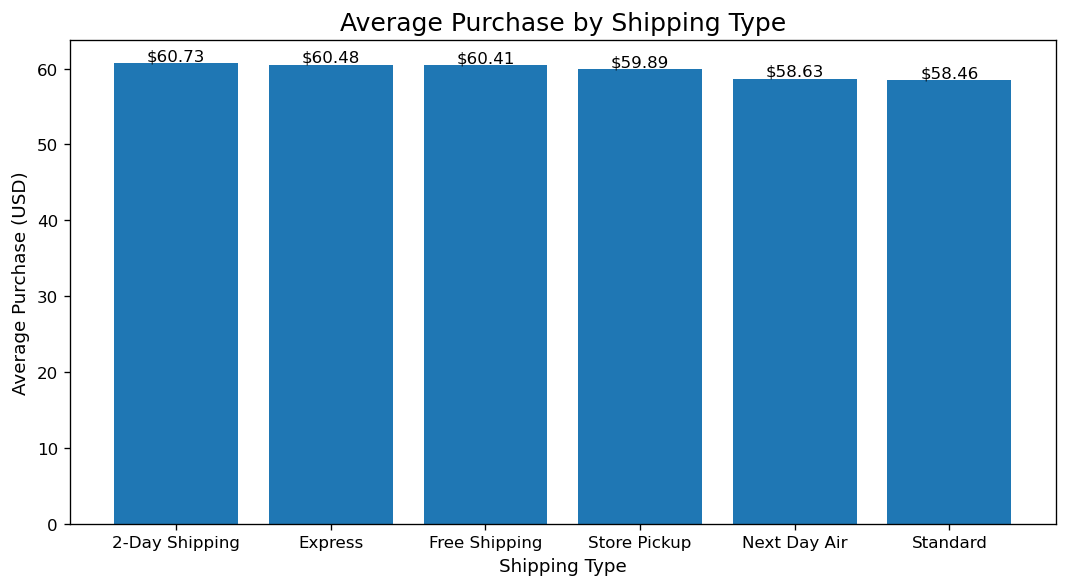

In [93]:
# Shipping type vs average purchase
shipping_avg = (
    df.groupby("shipping_type")["purchase_amount"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(shipping_avg.index, shipping_avg.values)
plt.title("Average Purchase by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Average Purchase (USD)")

for bar, value in zip(bars, shipping_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"${value:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(chart_dir / "12_shipping_average_purchase.png", bbox_inches="tight")
plt.show()


purchase_frequency_days
Weekly                         539
Fortnightly / Bi-Weekly       1089
Monthly                        553
Quarterly / Every 3 Months    1147
Annually                       572
Name: Transactions, dtype: int64

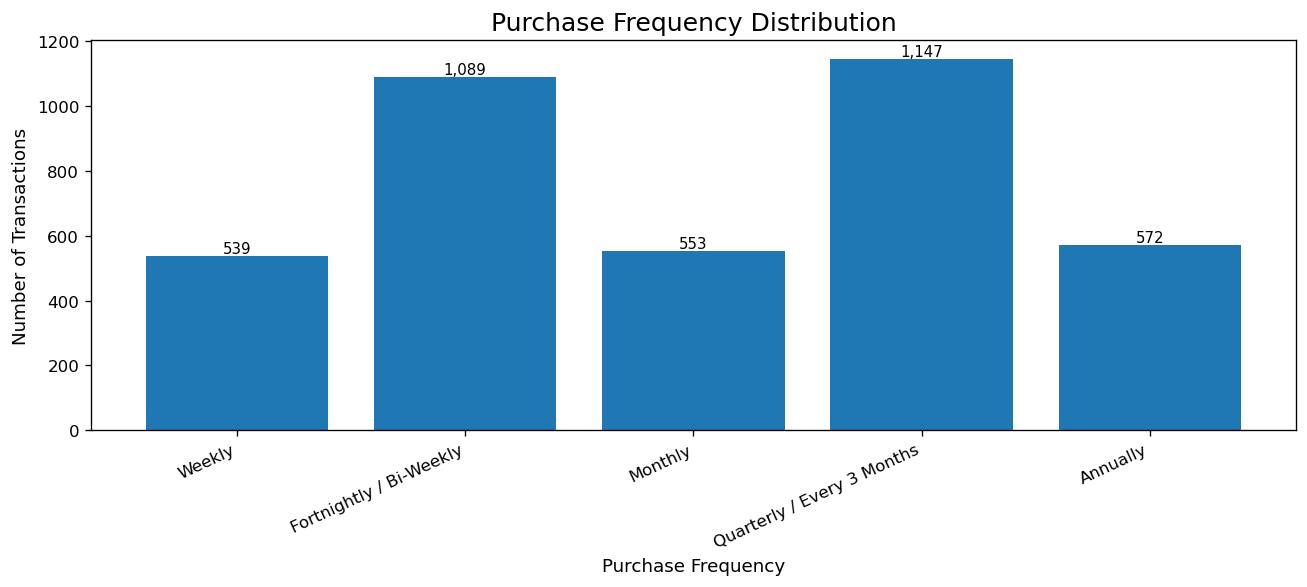

In [94]:
# Purchase frequency
frequency_order = (
    df.groupby("purchase_frequency_days")
      .size()
      .sort_index()
)

frequency_labels = {
    7: "Weekly",
    14: "Fortnightly / Bi-Weekly",
    30: "Monthly",
    90: "Quarterly / Every 3 Months",
    365: "Annually"
}

display(
    frequency_order.rename(index=frequency_labels).rename("Transactions")
)

plt.figure(figsize=(11, 5))
bars = plt.bar(
    [frequency_labels.get(i, str(i)) for i in frequency_order.index],
    frequency_order.values
)
plt.title("Purchase Frequency Distribution")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, frequency_order.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{value:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(chart_dir / "13_purchase_frequency.png", bbox_inches="tight")
plt.show()


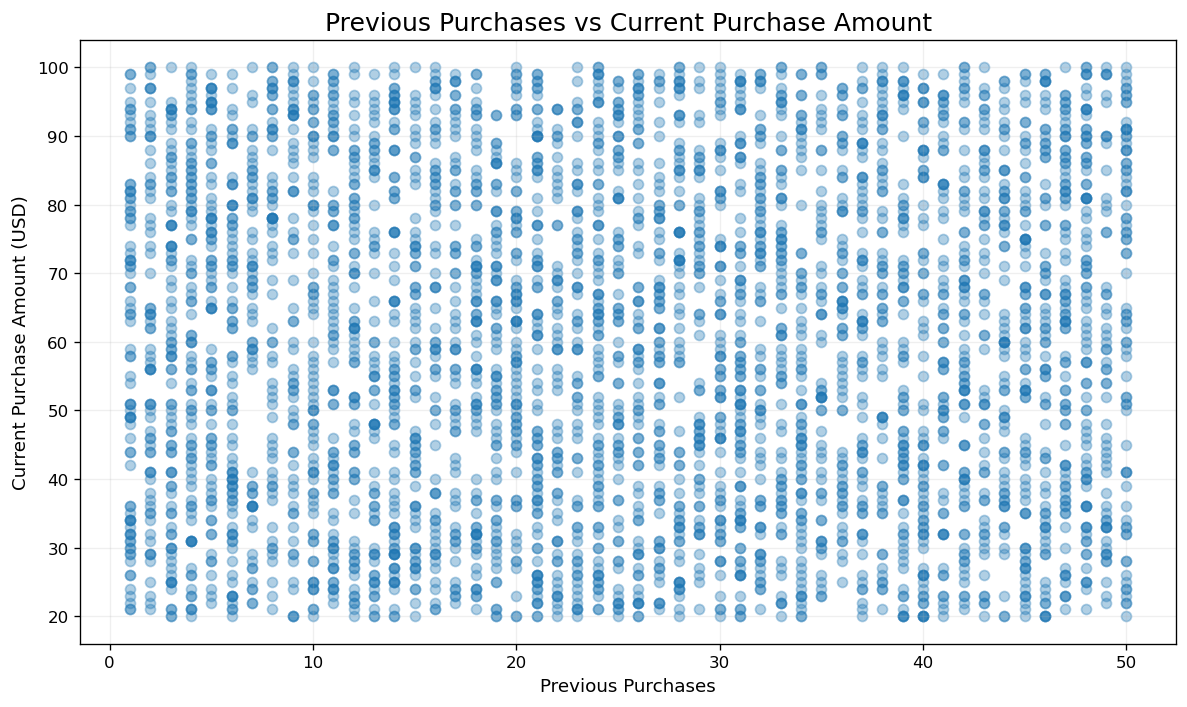

In [95]:
# Previous purchases vs purchase amount
plt.figure(figsize=(10, 6))
plt.scatter(
    df["previous_purchases"],
    df["purchase_amount"],
    alpha=0.35
)
plt.title("Previous Purchases vs Current Purchase Amount")
plt.xlabel("Previous Purchases")
plt.ylabel("Current Purchase Amount (USD)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(chart_dir / "14_previous_purchases_vs_amount.png", bbox_inches="tight")
plt.show()


## 6. Business Insights

In [96]:
# Automatically calculate a few headline findings for the report

top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

top_product = top_products.idxmax()
top_product_revenue = top_products.max()

top_gender = gender_revenue.idxmax()
top_gender_revenue = gender_revenue.max()

top_age_group = age_revenue.idxmax()
top_age_revenue = age_revenue.max()

loyal_share = (
    segment_counts["Loyal"] / segment_counts.sum() * 100
)

subscriber_avg = subscription_summary.loc["Yes", "Avg_Purchase"] if "Yes" in subscription_summary.index else np.nan
non_subscriber_avg = subscription_summary.loc["No", "Avg_Purchase"] if "No" in subscription_summary.index else np.nan

insights = [
    f"• {top_category} is the highest-revenue category, generating ${top_category_revenue:,.0f}.",
    f"• {top_product} is the highest-revenue product among individual products, generating ${top_product_revenue:,.0f}.",
    f"• {top_gender} customers account for the largest revenue contribution at ${top_gender_revenue:,.0f}.",
    f"• {top_age_group} is the highest-revenue age group at ${top_age_revenue:,.0f}.",
    f"• Loyal customers represent approximately {loyal_share:.1f}% of transaction records under the project's segment definition.",
    f"• The overall discount application rate is {discount_rate:.1f}%.",
    f"• Subscriber average purchase is ${subscriber_avg:.2f}, compared with ${non_subscriber_avg:.2f} for non-subscribers."
]

for insight in insights:
    print(insight)


• Clothing is the highest-revenue category, generating $104,264.
• Blouse is the highest-revenue product among individual products, generating $10,410.
• Male customers account for the largest revenue contribution at $157,890.
• Young Adult is the highest-revenue age group at $62,143.
• Loyal customers represent approximately 79.9% of transaction records under the project's segment definition.
• The overall discount application rate is 43.0%.
• Subscriber average purchase is $59.49, compared with $59.87 for non-subscribers.




**Raw data → Data cleaning → Feature engineering → SQL analysis → Python EDA → Visualization → Business insights**

